# 03 — Multiple Regression & Conclusion

Multiple regression combining maternal education, age, and IQ; correlation heatmap; model diagnostics; and overall conclusions.

### Multiple Regression for Education Level and Maternal Age for PPVT scores

In [1]:
import pandas as pd
import statsmodels.api as sm

# Read the dataset
dataCH = pd.read_csv('../data/child_iq_outliers_removed.csv')

# Check the column names
print(dataCH.columns)

# Ensure 'momage' and 'ppvt' are numeric
dataCH['momage'] = pd.to_numeric(dataCH['mom age (childbirth age)'], errors='coerce')
dataCH['ppvt'] = pd.to_numeric(dataCH['ppvt (child test score)'], errors='coerce')

# Ensure 'educ_cat' is categorical
dataCH['educ_cat'] = dataCH['educ_cat (mother education level)'].astype('category')

# Drop rows with NaN values in the relevant columns
dataCH = dataCH.dropna(subset=['momage', 'ppvt', 'educ_cat'])

# Run the regression using the formula interface
model = sm.OLS.from_formula("ppvt ~ momage + C(educ_cat)", data=dataCH)

# Fit the model
result = model.fit()

# Output the regression results
print(result.summary())

Index(['A', 'ppvt (child test score)', 'educ_cat (mother education level)',
       'mom age (childbirth age)'],
      dtype='str')
                            OLS Regression Results                            
Dep. Variable:                   ppvt   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     7.044
Date:                Mon, 17 Aug 2026   Prob (F-statistic):           1.77e-05
Time:                        19:58:32   Log-Likelihood:                -1656.3
No. Observations:                 382   AIC:                             3323.
Df Residuals:                     377   BIC:                             3342.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0

The R-squared value is 0.07 which suggests that only 7 percent of the variation in ppvt can be accounted by the combined model. However, this analysis is crucial for two main reasons - 

The above block is important in statistically proving the significant involvement of maternal education in predicting child ppvt scores, which uptil now was only deduced by box plots in this project. The p-values 0.001, 0.009 and 0.000 are all significant - highlighting that mother's education has a statistically strong positive impact on ppvt scores and that this magnitude of effect increases at higher levels. 

An important outcome to notice is that in the initial regression analysis for the first data set, despite weak linear relationship, maternal age was still a significant predictor of child intelligence. However, in the multiple linear regression model presented by the block above, where maternal age and education level were included as separate variables, maternal age was no longer significant. This suggests that the initial significance of maternal age was confounded by its correlation with education level. The multiple regression results indicate that maternal education level is a more important factor influencing child outcomes compared to maternal age.

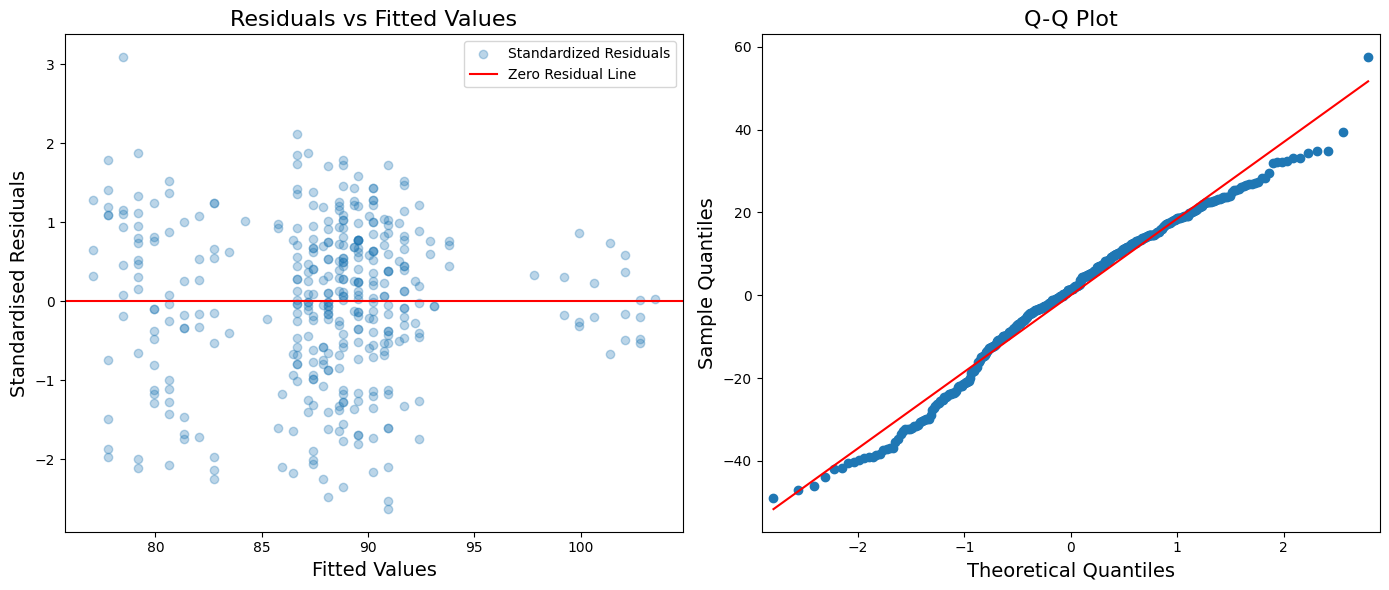

In [2]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Reuse the model fitted above (rather than refitting on stale variables)
# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# Residuals vs Fitted Values plot
axes[0].scatter(result.fittedvalues, result.resid_pearson, alpha=0.3, label="Standardized Residuals")
axes[0].axhline(y=0, color='red', linestyle='-', label="Zero Residual Line")  # Horizontal line at y=0
axes[0].set_xlabel("Fitted Values", fontsize=14)
axes[0].set_ylabel("Standardised Residuals", fontsize=14)
axes[0].set_title("Residuals vs Fitted Values", fontsize=16)
axes[0].legend()

# Q-Q Plot
sm.qqplot(result.resid, line='s', ax=axes[1])
axes[1].set_xlabel("Theoretical Quantiles", fontsize=14)
axes[1].set_ylabel("Sample Quantiles", fontsize=14)
axes[1].set_title("Q-Q Plot", fontsize=16)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

Similar to the use of residual vs fitted values plots and Q-Q plots in confirming the reliability of the linear regression model before, the plots produced in the block above confirm the accuracy of the results produced by the multiple regression model used. The closeness of data points to the red line in the Q-Q plot help confirm the assumption of normality of residuals and the random distribution of data points around the red-dotted line in the residuals vs fitted values plot helps eliminate systemic bias in the results.

Before carrying out the multiple regression analysis for our second data set involving kid IQ scores, we wanted to use a heatmap to summarise the correlation strengths of our independent variables and dependent variable since up until now, all our results pointed towards the requirement for the introduction of another potential factor when investigating mother's characteristics and child intelligence. 

### Correlation analysis between mom_age, mom_hs and kid_iq

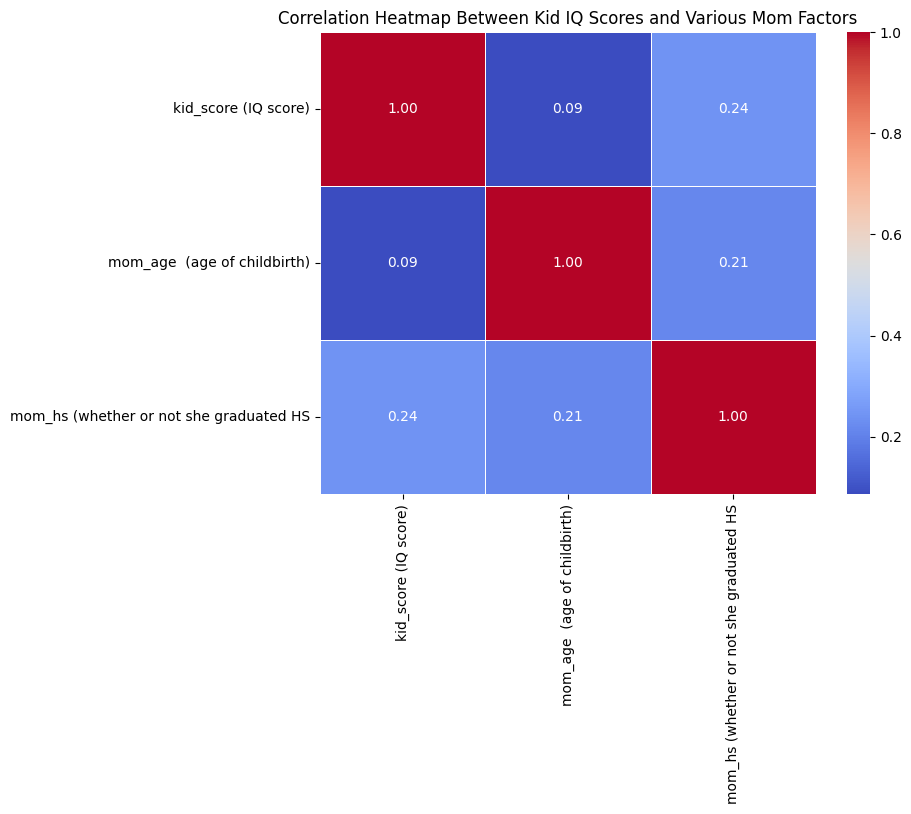

In [3]:
import pandas as pd
import seaborn as sns #seaborn is required here as it provides visualisations out of the scope of matplotlib
import matplotlib.pyplot as plt

# Load the dataset
kid_iq_outliers_removed = pd.read_csv('../data/kid_iq_outliers_removed.csv')

# Select the relevant columns
variables = ['kid_score (IQ score)', 'mom_age  (age of childbirth)', 'mom_hs (whether or not she graduated HS']
# Create the correlation matrix
correlation_matrix = kid_iq_outliers_removed[variables].corr()
# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap Between Kid IQ Scores and Various Mom Factors')
plt.show()


The heatmap above provides a visualisation for the correlation between child IQ scores and the maternal factors (age and education). Maternal education levels seemed to have a more evident effect on child IQ in comparison to the maternal age at childbirth. The heatmap also presents the relationship between our IVs - maternal age and education, where there is a weak positive correlation indicating older mothers are slightly more likely to be high school graduates. Both IVs seemed to produce a correlation with child IQ however these were found to be quite weak. This confirmed the idea of other factors that may play a major part in influencing the child's intelligence.

Why did we suddenly introduce mom IQ as variable? 

The need to consider an alternative variable led us to introducing mom IQ from the second dataset when conducting a multiple regression analysis for child IQ scores. Before this, we confirmed the involvement of mom IQ in predicting child IQ by producing a simple scatterplot analysis.

Slope: 0.590396758283514, Intercept: 27.759488736904032, Correlation: 0.4377244909116166


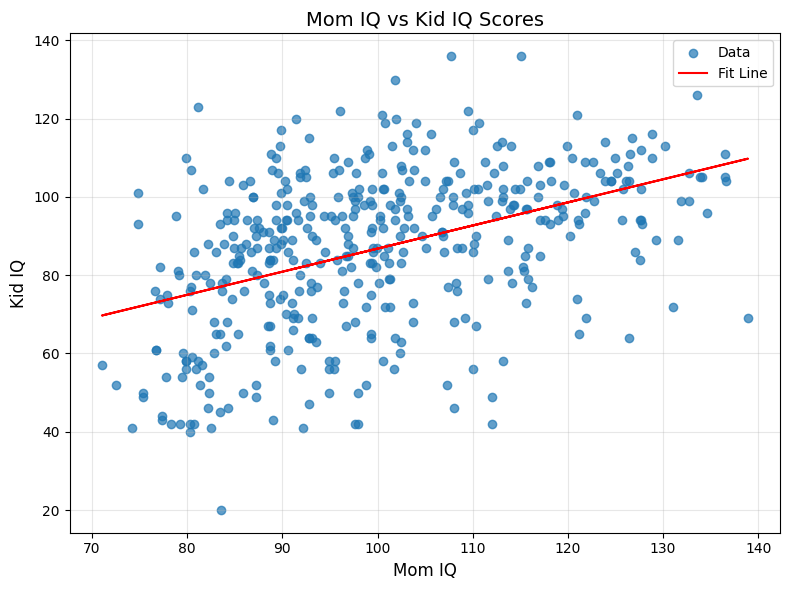

goodness of fit: 0.1916027299438339


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
kidData = pd.read_csv('../data/kid_iq_outliers_removed.csv')
slope, intercept, r_value, _, _ = linregress(kidData['mom_iq'], kidData['kid_score (IQ score)'])
goodnessoffit1 = r_value * r_value
print(f"Slope: {slope}, Intercept: {intercept}, Correlation: {r_value}")
#plot the axis 
plt.figure(figsize=(8, 6))
plt.scatter(kidData['mom_iq'], kidData['kid_score (IQ score)'], label='Data', alpha=0.7)
plt.plot(kidData['mom_iq'], intercept + slope *kidData['mom_iq'], color='red', label='Fit Line')
plt.xlabel('Mom IQ', fontsize=12)
plt.ylabel('Kid IQ', fontsize=12)
plt.title("Mom IQ vs Kid IQ Scores", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Show the plots
plt.show()

# Goodness of fit for to check fit of data to regression line
goodnessoffit3 = r_value*r_value
print (f"goodness of fit: {goodnessoffit3}")

The line of best fit for the graph shows a positive slope suggesting that with increase in mom's IQ, the kid's IQ increases. The low value of the correlation coefficient (0.4) suggests a moderate correlation, however, it's still better than when maternal and education are considered individually as seen in the heatmap. Further, the goodness of fit value is calculated to indicate how well the regression line fits to the data. The value of 0.19 implies that 19 percent of the variability in kid IQ can be attributed to mom IQ - which is low but still better than our other independent variables.

This analysis supports the decision to investigate mom IQ as a factor influencing child IQ, hence the following blocks aim to investigate the combined effects of maternal IQ, age and educational level on child IQ.

## Multiple Regression for Education Level, Maternal Age and Mom IQ with Child IQ

In [5]:
import statsmodels.api as sm
import pandas as pd

# Load the dataset
kid_iq_outliers_removed = pd.read_csv('../data/kid_iq_outliers_removed.csv')

# Define the independent (X) and dependent (Y) variables
X = kid_iq_outliers_removed[['mom_age  (age of childbirth)','mom_hs (whether or not she graduated HS','mom_iq']]
Y = kid_iq_outliers_removed['kid_score (IQ score)']

# Add a constant for the intercept
X = sm.add_constant(X)

# Fit the multiple linear regression model
model = sm.OLS(Y, X).fit()

# Print the regression summary
print(model.summary())

r_squared = model.rsquared
adjusted_r_squared = model.rsquared_adj
f_stat = model.fvalue
f_pvalue = model.f_pvalue


print("Regression Metrics:")
print(f"R-squared: {r_squared:.4f}")
print(f"Adjusted R-squared: {adjusted_r_squared:.4f}")
print(f"F-statistic: {f_stat:.4f}")
print(f"F-statistic p-value: {f_pvalue:.4e}")

                             OLS Regression Results                             
Dep. Variable:     kid_score (IQ score)   R-squared:                       0.207
Model:                              OLS   Adj. R-squared:                  0.201
Method:                   Least Squares   F-statistic:                     37.22
Date:                  Mon, 17 Aug 2026   Prob (F-statistic):           2.16e-21
Time:                          19:58:33   Log-Likelihood:                -1859.5
No. Observations:                   432   AIC:                             3727.
Df Residuals:                       428   BIC:                             3743.
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

The multiple regression analysis produced a high F-statistic (37.22) and extremely low p-value (2.16 x 10^-21) indicating statistical significance of the model and therefore suggesting the independent variables have a stronger, more significant influence on the dependent variable when considered collectively rather than individually. The R-squared value of 0.207 means that 20 percent of the variance in kid IQ scores can be attributed to the model which considers maternal age, education and IQ - this number being the highest R-squared value obtained throughout our project - re-affirming the importance of having a multivariate evaluation in this topic. 

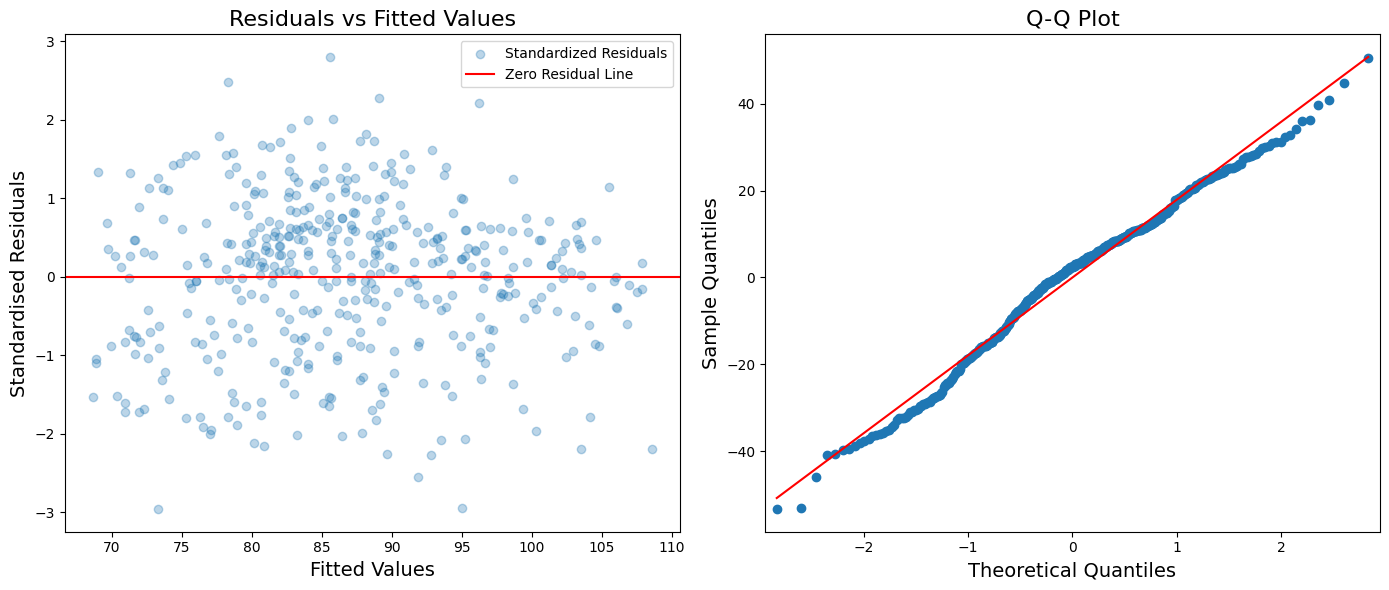

In [6]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Reuse the model fitted above (rather than refitting on stale variables)
# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# Residuals vs Fitted Values plot
axes[0].scatter(model.fittedvalues, model.resid_pearson, alpha=0.3, label="Standardized Residuals")
axes[0].axhline(y=0, color='red', linestyle='-', label="Zero Residual Line")  # Horizontal line at y=0
axes[0].set_xlabel("Fitted Values", fontsize=14)
axes[0].set_ylabel("Standardised Residuals", fontsize=14)
axes[0].set_title("Residuals vs Fitted Values", fontsize=16)
axes[0].legend()

# Q-Q Plot
sm.qqplot(model.resid, line='s', ax=axes[1])
axes[1].set_xlabel("Theoretical Quantiles", fontsize=14)
axes[1].set_ylabel("Sample Quantiles", fontsize=14)
axes[1].set_title("Q-Q Plot", fontsize=16)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

The residuals in this regression appear to be randomly scattered around the zero residual line, indicating that the assumption of homoscedasticity has been met and systemic bias is eliminated. Moreover, the Q-Q plot shows the sample quartiles follow close to the theoretical quantiles line, suggesting that the residuals follow a normal distribution. Hence the supplementing plots for the multiple regression confirm its reliability in predicting kid iq scores.

## Conclusion

We set out with the goal of investigating maternal factors as predictors of child intelligence. Our original hypothesis included maternal education level and age and we set out with two datasets - one with ppvt scores and one with kid iq scores - both indicative of child intelligence. Exploratory data analysis was carried out and following that education levels were investigated using box plots.

The box plots showed that education levels seemed to have an effect on ppvt and IQ scores - so we could continue with maternal education as an appropriate independent variable. Regression analysis of mom's age and child intelligence was then carried out by conducting individual linear regression tests supplemented with residual plots and Q-Q plots to justify the involvement of maternal age as a possible independent variable.

Results for this comprehensive analysis in both datasets revealed that despite following statistical significance, maternal age had a weak relationship with both ppvt scores and child IQ scores. Now, we added education attainment levels and conducted a multiple regression analysis using education levels and maternal age on ppvt scores from our first dataset. Education levels did show a significant additive effect but the R-squared value from that still begged the involvement of another variable. 

A positive aspect of our second dataset was that it also investigated mom IQ as a possible variable, and we considered adding it and seeing if the collective effect of mom IQ, maternal age and maternal education level was better than when individually assessed. On the other hand, the ppvt score data was extremely limited on its own as the lack of other variables such as mom IQ, prevented us from investigating an additive effect like we did for the kid IQ dataset.

Reflecting on the conclusions drawn from the analysis, several strengths and weaknesses emerged. The primary strengths included the use of OLS regression and permutation tests, allowing for robust statistical analysis and the control of confounding variables. The model's statistical significance was evidenced by the high F-statistic and low p-values in both regressions. However, the moderate R-squared value of 0.07 for the PPVT scores and 0.2 for IQ scores indicated that only a portion of the variance was explained, suggesting the presence of other influential factors not included in the model. Additionally, the small dataset posed a risk of overfitting, and assumptions of linearity and normality, though mostly met, should be considered cautiously due to the outliers in the tails of the Q-Q plot.

In the end, we deduced that a multivariate analysis was required in studying the effects of maternal characteristics on child intelligence. As we kept adding variables that could possibly impact our DV, the R-squared value kept increasing. Mother's IQ could be seen as an umbrella variable to be assessed thoroughly in future research along with many others like socio-economic conditions, financial background and so on. 

## References

Dunn, L. M., & Dunn, L. M. (1981). Peabody Picture Vocabulary Test-Revised. Circle Pines, MN: American Guidance Service. 

Lean, R. E., Paul, R. A., Smyser, C. D., & Rogers, C. E. (2018). Maternal intelligence quotient (IQ) predicts IQ and language in very preterm children at age 5 years. Journal of child psychology and psychiatry, and allied disciplines, 59(2), 150–159. https://doi.org/10.1111/jcpp.12810

Meador, K. J., Baker, G. A., Browning, N., Clayton-Smith, J., Cohen, M. J., Kalayjian, L. A., Kanner, A., Liporace, J. D., Pennell, P. B., Privitera, M., & Loring, D. W. (2011). Relationship of child IQ to parental IQ and education in children with fetal antiepileptic drug exposure. Epilepsy & behavior : E&B, 21(2), 147–152. https://doi.org/10.1016/j.yebeh.2011.03.020

Ramey, C. T., Farran, D. C., & Campbell, F. A. (1979). Predicting IQ from mother-infant interactions. Child development, 50(3), 804–814.

Ronfani, L., Vecchi Brumatti, L., Mariuz, M., Tognin, V., Bin, M., Ferluga, V., Knowles, A., Montico, M., & Barbone, F. (2015). The Complex Interaction between Home Environment, Socioeconomic Status, Maternal IQ and Early Child Neurocognitive Development: A Multivariate Analysis of Data Collected in a Newborn Cohort Study. PloS one, 10(5), e0127052. https://doi.org/10.1371/journal.pone.0127052

Veldkamp, S. A. M., Zondervan-Zwijnenburg, M. A. J., van Bergen, E., Barzeva, S. A., Tamayo-Martinez, N., Becht, A. I., … Hartman, C. (2020). Parental Age in Relation to Offspring’s Neurodevelopment. Journal of Clinical Child & Adolescent Psychology, 50(5), 632–644. https://doi.org/10.1080/15374416.2020.1756298